In [18]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [19]:
df = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")

In [20]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


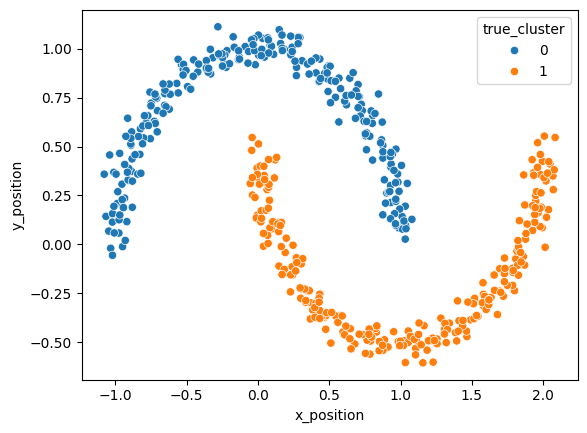

In [22]:
sns.scatterplot(data=df, x="x_position", y="y_position", hue="true_cluster")
plt.show()

In [23]:
# Özel hazırlanmış bir data set olduğu için zaten labellanmış şekilde verilmiş. Biz bu kolonu kaldırıp kendimiz labellamaya kümelemeye
# çalışacağız !!!

In [24]:
df = df.drop("true_cluster", axis=1)

In [25]:
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


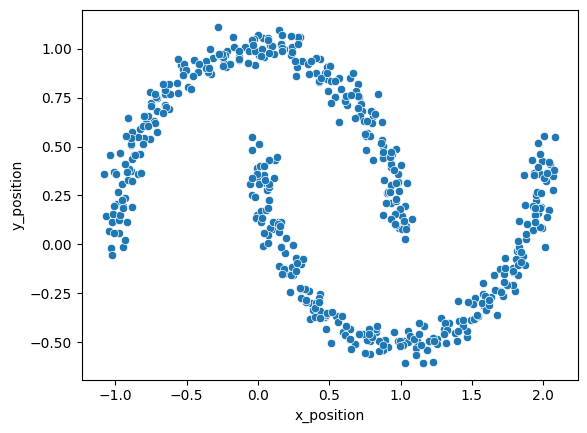

In [26]:
sns.scatterplot(data=df, x="x_position", y="y_position")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [28]:
X_scaled = scaler.fit_transform(df)

In [41]:
from sklearn.cluster import DBSCAN, HDBSCAN

In [30]:
dbs = DBSCAN() # eps -> 0.5 (DEFAULT)  min_sample -> 5 (DEFAULT)

In [31]:
dbs.fit(X_scaled)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [32]:
dbs.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [33]:
X_scaled = pd.DataFrame(X_scaled, columns=["x_position", "y_position"])

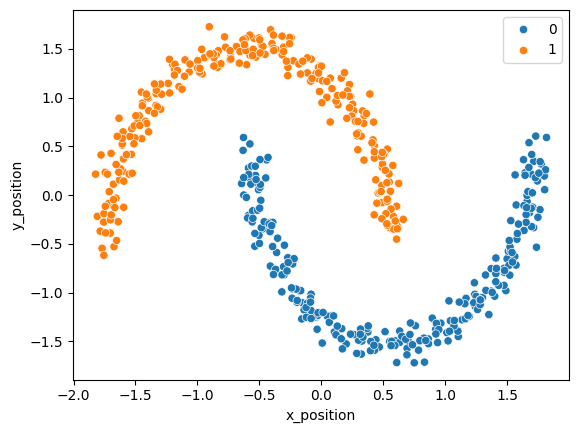

In [34]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbs.labels_)
plt.show()

In [35]:
# Görüldüğü gibi biz de doğru şekilde kümeleyebildik. 

In [36]:
eps_values = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6
]

min_sample_values = [4,5,6]

In [37]:
from sklearn.metrics import silhouette_score

In [39]:
result = []

for eps in eps_values:
    for min_samples in min_sample_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, labels)
        result.append({
            "eps": eps,
            "min_samples": min_samples,
            "silhouette_score": silhouette,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
        })

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by="silhouette_score", ascending=False)

In [40]:
result_df

,eps,min_samples,silhouette_score,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


In [42]:
hdbscan = HDBSCAN()

In [43]:
hdbscan.fit(X_scaled)

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [44]:
hdbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

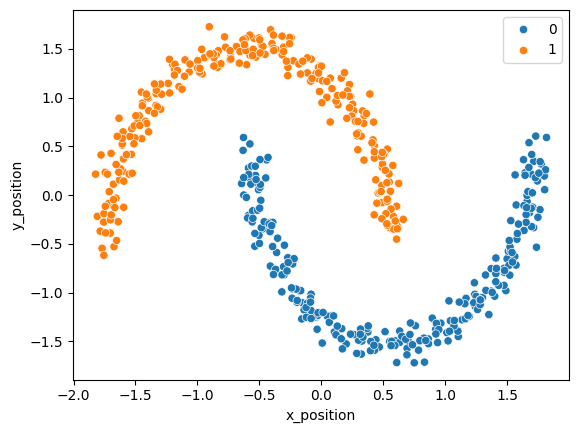

In [45]:
sns.scatterplot(data=X_scaled, x="x_position", y= "y_position", hue=hdbscan.labels_)
plt.show()

In [46]:
min_cluster_size = [3,5,7,10]
min_samples = [None, 3,5,7]

In [47]:
result = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, labels)
        result.append({
            "min_cluster_size": min_cluster,
            "min_samples": min_sample,
            "silhouette_score": silhouette,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
        })

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by="silhouette_score", ascending=False)

In [48]:
result_df

,min_cluster_size,min_samples,silhouette_score,n_clusters
3,3,7.0,0.389338,2
2,3,5.0,0.389338,2
5,5,3.0,0.389338,2
4,5,NaN,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
9,7,3.0,0.389338,2
8,7,NaN,0.389338,2
12,10,NaN,0.389338,2
13,10,3.0,0.389338,2
